# Main Model Training Code

The training code for both the main MobileNetV2 fine tuned model and for the baseline CNN classifier is included.  A confusion matrix is displayed also showing the results of the trained model.

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import os
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch.backends.cudnn as cudnn

# Enable optimizations
cudnn.benchmark = True
torch.backends.cudnn.enabled = True


class FER2013Dataset(Dataset):
    """Dataset class for FER2013 emotion recognition dataset"""

    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.images = []
        self.labels = []

        # Map emotion categories to labels
        self.emotion_map = {
            'angry': 0,
            'disgust': 1,
            'fear': 2,
            'happy': 3,
            'neutral': 4,
            'sad': 5,
            'surprise': 6
        }

        # Load images and labels
        for emotion in self.emotion_map.keys():
            emotion_dir = os.path.join(data_dir, emotion)
            if os.path.exists(emotion_dir):
                for img_file in os.listdir(emotion_dir):
                    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        img_path = os.path.join(emotion_dir, img_file)
                        self.images.append(img_path)
                        self.labels.append(self.emotion_map[emotion])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        # Load image with error handling
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # If image fails to load, create a black image
            print(f"Warning: Failed to load {img_path}: {e}")
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        return image, label


class BaselineCNN(nn.Module):  # FIXED: Changed from cnn.Module to nn.Module
    """Baseline CNN for emotion recognition"""

    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()  # FIXED: Added parentheses

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Input is 32, not 128
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 256, kernel_size=3, padding=1),  # FIXED: Changed from 128 to 64
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # FIXED: Corrected dimensions - 224->112->56->28, so 28x28 not 14x14
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 28 * 28, 512),  # FIXED: Changed from 14*14 to 28*28
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class EmotionRecognizer(nn.Module):
    """MobileNetV2-based emotion recognition model"""

    def __init__(self, num_classes=7, pretrained=True):
        super(EmotionRecognizer, self).__init__()

        # Load pretrained MobileNetV2
        if pretrained:
            weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
        else:
            weights = None
        self.backbone = models.mobilenet_v2(weights=weights)

        # Replace the classifier
        # MobileNetV2's classifier has 1280 input features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


def train_model(model, train_loader, val_loader, num_epochs=50, device='cuda',
                learning_rate=0.001, save_path='best_model.pth', use_amp=True):
    """Train the emotion recognition model with mixed precision training"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Mixed precision scaler for faster training
    scaler = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None

    best_val_acc = 0.0
    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for images, labels in train_bar:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            # Forward pass with mixed precision
            optimizer.zero_grad()
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                # Backward pass with scaler
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            # Statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            train_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * train_correct / train_total:.2f}%'
            })

        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
            for images, labels in val_bar:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

                if scaler is not None:
                    with torch.cuda.amp.autocast():
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                val_bar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100 * val_correct / val_total:.2f}%'
                })

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total
        val_accuracies.append(val_acc)

        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'  Learning Rate: {current_lr:.6f}\n')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': avg_val_loss,
            }, save_path)
            print(f'✓ Saved best model with validation accuracy: {val_acc:.2f}%\n')

    return train_losses, val_accuracies


def evaluate_model(model, test_loader, device='cuda'):
    """Evaluate the model on test set"""

    model.eval()
    all_preds = []
    all_labels = []

    emotion_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

    with torch.no_grad():
        test_bar = tqdm(test_loader, desc='Testing')
        for images, labels in test_bar:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)

    print(f'\nTest Accuracy: {accuracy * 100:.2f}%')
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=emotion_names))

    print('\nConfusion Matrix:')
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)

    return accuracy, cm


def main():
    # Configuration
    DATA_DIR = '/content/FER2013'
    TRAIN_DIR = os.path.join(DATA_DIR, 'train')
    TEST_DIR = os.path.join(DATA_DIR, 'test')
    BATCH_SIZE = 128  # Increased for better GPU utilization
    NUM_EPOCHS = 8
    LEARNING_RATE = 0.001
    NUM_WORKERS = min(8, os.cpu_count() or 1)
    IMG_SIZE = 224

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    use_amp = device.type == 'cuda'

    print(f'Using device: {device}')
    print(f'Mixed precision training: {use_amp}')
    print(f'Data loader workers: {NUM_WORKERS}')
    print(f'Batch size: {BATCH_SIZE}\n')

    # Data transformations
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create datasets
    print('Loading datasets...')
    full_train_dataset = FER2013Dataset(TRAIN_DIR, transform=train_transform)

    # Split train into train and validation (80-20 split)
    dataset_size = len(full_train_dataset)
    train_size = int(0.8 * dataset_size)

    indices = np.arange(dataset_size)
    np.random.seed(42)
    np.random.shuffle(indices)
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    # Create separate datasets with appropriate transforms
    train_dataset_full = FER2013Dataset(TRAIN_DIR, transform=train_transform)
    val_dataset_full = FER2013Dataset(TRAIN_DIR, transform=val_test_transform)

    train_dataset = torch.utils.data.Subset(train_dataset_full, train_indices)
    val_dataset = torch.utils.data.Subset(val_dataset_full, val_indices)
    test_dataset = FER2013Dataset(TEST_DIR, transform=val_test_transform)

    print(f'Train samples: {len(train_dataset)}')
    print(f'Validation samples: {len(val_dataset)}')
    print(f'Test samples: {len(test_dataset)}\n')

    # Create data loaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=True if NUM_WORKERS > 0 else False,
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
        drop_last=False
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=True if NUM_WORKERS > 0 else False,
        prefetch_factor=2 if NUM_WORKERS > 0 else None
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=True if NUM_WORKERS > 0 else False,
        prefetch_factor=2 if NUM_WORKERS > 0 else None
    )

    # CNN MODEL


    # Create baseline CNN model
    #print('Creating baseline CNN model...')
    #model = BaselineCNN(num_classes=7).to(device)

    #if hasattr(torch, 'compile') and device.type == 'cuda':
    #    print('Compiling model for faster training...')
    #    model = torch.compile(model, mode='reduce-overhead')


    print('Creating MobileNetV2 model...')
    model = EmotionRecognizer(num_classes=7, pretrained=True).to(device)


    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters: {total_params:,}')
    print(f'Trainable parameters: {trainable_params:,}\n')

    # Train model
    print('Starting training...\n')
    train_losses, val_accuracies = train_model(
        model, train_loader, val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        learning_rate=LEARNING_RATE,
        save_path='best_emotion_model.pth',
        use_amp=use_amp
    )

    # Load best model and evaluate on test set
    print('Loading best model for testing...')
    checkpoint = torch.load('best_emotion_model.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    print('\nEvaluating on test set...')
    test_accuracy, confusion_mat = evaluate_model(model, test_loader, device=device)

    print(f'\nTraining completed!')
    print(f'Best validation accuracy: {checkpoint["val_acc"]:.2f}%')
    print(f'Test accuracy: {test_accuracy * 100:.2f}%')


if __name__ == '__main__':
    main()

Using device: cuda
Mixed precision training: True
Data loader workers: 8
Batch size: 128

Loading datasets...
Train samples: 21060
Validation samples: 5265
Test samples: 6563

Creating MobileNetV2 model...


/tmp/ipython-input-934175002.py:140: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None


Total parameters: 2,232,839
Trainable parameters: 2,232,839

Starting training...



Epoch 1/8 [Train]:   0%|          | 0/165 [00:00<?, ?it/s]/tmp/ipython-input-934175002.py:160: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/8 [Val]:   0%|          | 0/42 [00:00<?, ?it/s]/tmp/ipython-input-934175002.py:203: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/8 [Val]: 100%|██████████| 42/42 [00:07<00:00,  5.79it/s, loss=0.7544, acc=56.51%]



Epoch 1/8:
  Train Loss: 1.2752, Train Acc: 50.78%
  Val Loss: 1.1104, Val Acc: 56.51%
  Learning Rate: 0.001000

✓ Saved best model with validation accuracy: 56.51%



...


Epoch 7/8:
  Train Loss: 0.8579, Train Acc: 67.55%
  Val Loss: 0.9726, Val Acc: 63.27%
  Learning Rate: 0.001000

✓ Saved best model with validation accuracy: 63.27%



Epoch 8/8 [Val]: 100%|██████████| 42/42 [00:03<00:00, 12.07it/s, loss=0.6575, acc=64.62%]



Epoch 8/8:
  Train Loss: 0.8284, Train Acc: 68.97%
  Val Loss: 0.9655, Val Acc: 64.62%
  Learning Rate: 0.001000

✓ Saved best model with validation accuracy: 64.62%

Loading best model for testing...

Evaluating on test set...


Testing: 100%|██████████| 52/52 [00:07<00:00,  6.63it/s]



Test Accuracy: 62.24%

Classification Report:
              precision    recall  f1-score   support

       angry       0.56      0.62      0.59       958
     disgust       0.50      0.48      0.49       111
        fear       0.55      0.32      0.40      1024
       happy       0.81      0.85      0.83      1159
     neutral       0.56      0.65      0.60      1233
         sad       0.52      0.60      0.55      1247
    surprise       0.81      0.71      0.75       831

    accuracy                           0.62      6563
   macro avg       0.61      0.60      0.60      6563
weighted avg       0.62      0.62      0.62      6563


Confusion Matrix:
[[590  24  54  25 106 148  11]
 [ 44  53   7   1   0   6   0]
 [152  13 323  18 154 280  84]
 [ 42   3  29 983  53  31  18]
 [ 77   6  30  95 805 210  10]
 [113   4  55  48 266 745  16]
 [ 33   3  94  44  49  22 586]]

Training completed!
Best validation accuracy: 64.62%
Test accuracy: 62.24%


# Model loading code

In [40]:
import os, numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Model must match your checkpoint (MobileNetV2)
class EmotionRecognizer(nn.Module):
    def __init__(self, num_classes=7, pretrained=False):
        super().__init__()
        self.backbone = models.mobilenet_v2(weights=None)
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionRecognizer(num_classes=7).to(device)

ckpt = torch.load("best_emotion_model.pth", map_location=device)
state = ckpt["model_state_dict"] if (isinstance(ckpt, dict) and "model_state_dict" in ckpt) else ckpt

# strip torch.compile prefix if present
fixed = { (k[len("_orig_mod."):] if k.startswith("_orig_mod.") else k): v for k,v in state.items() }

model.load_state_dict(fixed, strict=True)
model.eval()

IMG_SIZE = 224
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
print("Loaded model OK.")


Loaded model OK.


# Model Fairness Analysis

The code below is the main component for the deliverable regarding model fairness.  It computes the accuracy statistics across the labeled demographic images.

In [56]:
import numpy as np, pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

# ---- 1) rebuild eval_loader ----
CSV_PATH = "/content/fer2013_demographics.csv"
IMAGES_ROOT = "/content/FER2013_labeled_images/images"

labeled_ds = LabeledFERImages(CSV_PATH, IMAGES_ROOT, transform=tfm)
eval_loader = DataLoader(labeled_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("Matched labeled images:", len(labeled_ds))

# ---- 2) inference ----
@torch.no_grad()
def run_inference(model, loader, device):
    ys, ps, genders, races = [], [], [], []
    for x, y, g, r in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        ys.extend(y.numpy())
        ps.extend(preds)
        genders.extend(list(g))
        races.extend(list(r))
    return np.array(ys), np.array(ps), np.array(genders), np.array(races)

def subgroup_table_race_gender(y_true, y_pred, genders, races):
    overall = accuracy_score(y_true, y_pred)
    rows = []

    # Gender
    for g in np.unique(genders):
        idx = genders == g
        rows.append(("gender", g, int(idx.sum()), accuracy_score(y_true[idx], y_pred[idx])))

    # Race
    for r in np.unique(races):
        idx = races == r
        rows.append(("race", r, int(idx.sum()), accuracy_score(y_true[idx], y_pred[idx])))

    df = pd.DataFrame(rows, columns=["group_type", "group", "n", "accuracy"])
    df["gap_vs_overall"] = df["accuracy"] - overall
    return overall, df.reset_index(drop=True)

y_true, y_pred, genders, races = run_inference(model, eval_loader, device)
overall, fairness_df = subgroup_table_race_gender(y_true, y_pred, genders, races)

print("Overall accuracy:", overall)
display(fairness_df.sort_values(["group_type", "accuracy"]))


Matched labeled images: 1040
Overall accuracy: 0.8548076923076923


,group_type,group,n,accuracy,gap_vs_overall
1,gender,Male,431,0.823666,-0.031142
0,gender,Female,609,0.876847,0.022040
6,race,White,788,0.848985,-0.005823
3,race,Black,117,0.863248,0.008440
4,race,Latino/Hispanic,16,0.875000,0.020192
2,race,Asian,118,0.881356,0.026548
5,race,Other,1,1.000000,0.145192


# Code to move demographic label images to separate folder

The following were a series of cells that were necessary to move the demographically labeled images out of the train folder to avoid training on them.  Then, they were stored separately to allow for training

In [34]:
import os, shutil
import pandas as pd

CSV_PATH   = "/content/fer2013_demographics.csv"
FER_ROOT   = "/content/FER2013"
TRAIN_ROOT = os.path.join(FER_ROOT, "train")
LABELED_ROOT = "/content/FER2013_labeled_images"

df = pd.read_csv(CSV_PATH)
df["file"] = df["file"].astype(str).str.strip()  # e.g., "happy/Training_50449107.jpg"

# Create destination root
os.makedirs(LABELED_ROOT, exist_ok=True)

copied = 0
missing = 0
already = 0

for rel in df["file"].tolist():
    src = os.path.join(TRAIN_ROOT, rel)  # /content/FER2013/train/happy/Training_....jpg
    dst = os.path.join(LABELED_ROOT, rel)

    if not os.path.exists(src):
        missing += 1
        continue

    os.makedirs(os.path.dirname(dst), exist_ok=True)

    if os.path.exists(dst):
        already += 1
        continue

    shutil.copy2(src, dst)
    copied += 1

print("Copied:", copied, "Already existed:", already, "Missing in train:", missing)
print("Labeled folder created at:", LABELED_ROOT)


Copied: 1040 Already existed: 0 Missing in train: 0
Labeled folder created at: /content/FER2013_labeled_images


In [35]:
import os

def count_images(root):
    total = 0
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.lower().endswith((".jpg",".jpeg",".png")):
                total += 1
    return total

print("CSV rows:", len(df))
print("Images in FER2013_labeled_images:", count_images(LABELED_ROOT))


CSV rows: 1040
Images in FER2013_labeled_images: 1040


In [36]:
removed = 0
missing = 0

for rel in df["file"].tolist():
    src = os.path.join(TRAIN_ROOT, rel)
    if os.path.exists(src):
        os.remove(src)
        removed += 1
    else:
        missing += 1

print("Removed from FER2013/train:", removed, "Missing (already gone):", missing)


Removed from FER2013/train: 1040 Missing (already gone): 0


# Heatmap Code

The code for the heatmap for the visualization deliverable

Matched labeled images: 1040
Overall accuracy: 0.8548076923076923


,group_type,group,n,accuracy,gap_vs_overall
0,gender,Female,609,0.876847,0.022040
1,gender,Male,431,0.823666,-0.031142
2,race,Asian,118,0.881356,0.026548
3,race,Black,117,0.863248,0.008440
4,race,Latino/Hispanic,16,0.875000,0.020192
5,race,Other,1,1.000000,0.145192
6,race,White,788,0.848985,-0.005823


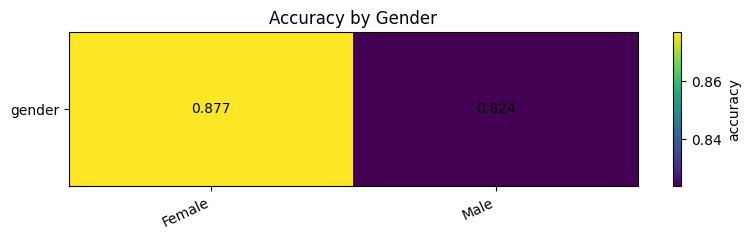

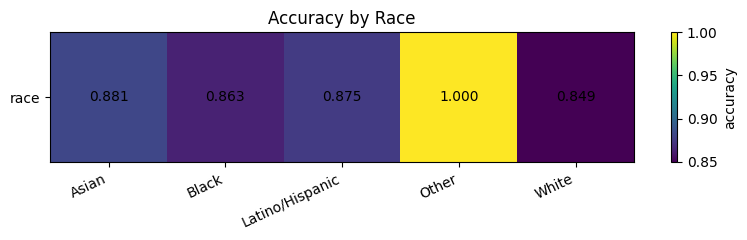

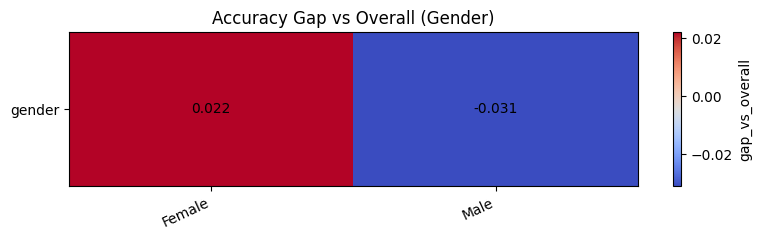

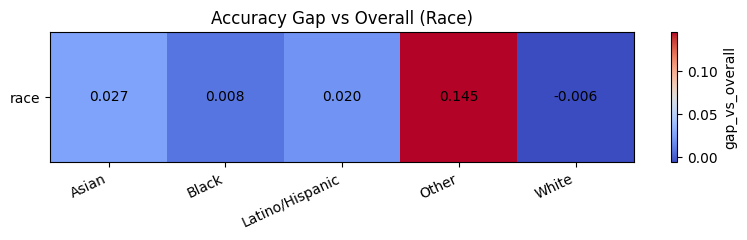

In [54]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

# ---- 1) rebuild eval_loader ----
CSV_PATH = "/content/fer2013_demographics.csv"
IMAGES_ROOT = "/content/FER2013_labeled_images/images"

labeled_ds = LabeledFERImages(CSV_PATH, IMAGES_ROOT, transform=tfm)
eval_loader = DataLoader(labeled_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("Matched labeled images:", len(labeled_ds))

# ---- 2) inference ----
@torch.no_grad()
def run_inference(model, loader, device):
    ys, ps, genders, races = [], [], [], []
    for x, y, g, r in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu().numpy()
        ys.extend(y.numpy())
        ps.extend(preds)
        genders.extend(list(g))
        races.extend(list(r))
    return np.array(ys), np.array(ps), np.array(genders), np.array(races)

def subgroup_table_race_gender(y_true, y_pred, genders, races):
    overall = accuracy_score(y_true, y_pred)
    rows = []

    # Gender
    for g in np.unique(genders):
        idx = genders == g
        rows.append(("gender", g, idx.sum(), accuracy_score(y_true[idx], y_pred[idx])))

    # Race
    for r in np.unique(races):
        idx = races == r
        rows.append(("race", r, idx.sum(), accuracy_score(y_true[idx], y_pred[idx])))

    df = pd.DataFrame(rows, columns=["group_type", "group", "n", "accuracy"])
    df["gap_vs_overall"] = df["accuracy"] - overall
    return overall, df.reset_index(drop=True)

y_true, y_pred, genders, races = run_inference(model, eval_loader, device)
overall, fairness_df = subgroup_table_race_gender(y_true, y_pred, genders, races)

print("Overall accuracy:", overall)
display(fairness_df)

# ---- 3) Heatmaps (NO intersections) ----

def single_dim_heatmap(df, group_type, value_col, title, cmap="viridis"):
    sub = df[df["group_type"] == group_type].copy()
    pivot = pd.DataFrame(
        sub[value_col].values.reshape(1, -1),
        columns=sub["group"].values,
        index=[group_type]
    )

    plt.figure(figsize=(8, 2.5))
    plt.imshow(pivot.values, aspect="auto", cmap=cmap)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=25, ha="right")
    plt.yticks([0], [group_type])
    plt.colorbar(label=value_col)
    plt.title(title)

    for j, v in enumerate(pivot.values[0]):
        plt.text(j, 0, f"{v:.3f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

# Accuracy heatmaps
single_dim_heatmap(
    fairness_df,
    group_type="gender",
    value_col="accuracy",
    title="Accuracy by Gender"
)

single_dim_heatmap(
    fairness_df,
    group_type="race",
    value_col="accuracy",
    title="Accuracy by Race"
)

# Gap vs overall heatmaps
single_dim_heatmap(
    fairness_df,
    group_type="gender",
    value_col="gap_vs_overall",
    title="Accuracy Gap vs Overall (Gender)",
    cmap="coolwarm"
)

single_dim_heatmap(
    fairness_df,
    group_type="race",
    value_col="gap_vs_overall",
    title="Accuracy Gap vs Overall (Race)",
    cmap="coolwarm"
)
